Here, a dataset is provided containing historical stock prices spanning the past 12 years for 29 companies from Yahoo Finance.

**Question: Stock Price Prediction using RNN and LSTM in PyTorch**

Use the historical stock prices dataset (saved as a .csv file) provided in the above code snippet for a company or more to implement a stock price prediction model using **RNN** and **LSTM** both in PyTorch. Train the models on historical stock price data and evaluate their performance. The goal is to predict the next day's closing price based on past stock prices.

**Requirements:**
1.   **Data Preprocessing:** Convert the dataset into sequences suitable for time-series forecasting. Consider using features like Open, High, Low, Close, and Volume.
1.   **Model Implementation:** Implement two models: one using a simple **RNN** and another using an **LSTM**.
2.   **Customized Loss Function:** Design a custom loss function that penalizes large errors more.
3.   **Training and Evaluation:**Train both models and compare their performance. Use a validation set to monitor performance.
4.   **Visualization:** Plot two graphs:
      *   Loss vs. Epochs
      *   Predicted vs. Actual Prices

In [1]:
import yfinance as yf
import pandas as pd
import pandas_datareader as pdr
import datetime
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
save_dir = "/content/drive/My Drive/stock_data"

In [5]:
start = datetime.datetime(2010, 1, 1)
end = datetime.datetime(2022, 1, 1)
start_date_str = str(start.date())
end_date_str = str(end.date())

In [6]:
stocks = [
    'MMM', 'AXP', 'AAPL', 'BA', 'CAT', 'CVX', 'CSCO', 'KO', 'DIS', 'XOM', 'GE',
    'GS', 'HD', 'IBM', 'INTC', 'JNJ', 'JPM', 'MCD', 'MRK', 'MSFT', 'NKE', 'PFE',
    'PG', 'TRV', 'UTX', 'UNH', 'VZ', 'WMT', 'GOOGL', 'AMZN'
]

In [7]:
for ticker in stocks:
    file_name = f"{save_dir}/{ticker}_{start_date_str}_to_{end_date_str}.csv"
    print(f"Fetching data for {ticker}...")

    # Download data using yfinance
    data = yf.download(ticker, start=start_date_str, end=end_date_str)

    if not data.empty:
        print(f"Saving {ticker} data to {file_name}")
        data.to_csv(file_name)
    else:
        print(f"No data found for {ticker}")

print("Data fetching complete!")

Fetching data for MMM...
YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed


Saving MMM data to /content/drive/My Drive/stock_data/MMM_2010-01-01_to_2022-01-01.csv
Fetching data for AXP...


[*********************100%***********************]  1 of 1 completed


Saving AXP data to /content/drive/My Drive/stock_data/AXP_2010-01-01_to_2022-01-01.csv
Fetching data for AAPL...


...

[*********************100%***********************]  1 of 1 completed

Fetching data for GOOGL...
Saving GOOGL data to /content/drive/My Drive/stock_data/GOOGL_2010-01-01_to_2022-01-01.csv



[*********************100%***********************]  1 of 1 completed

Fetching data for AMZN...
Saving AMZN data to /content/drive/My Drive/stock_data/AMZN_2010-01-01_to_2022-01-01.csv


Data fetching complete!


In [8]:
def load_stock_data(filename):
    if not os.path.exists(filename):
        print(f"File {filename} not found.")
        exit()

    # Read CSV while skipping the first two rows
    df = pd.read_csv(filename, skiprows=2)

    # Strip any whitespace from column names
    df.columns = df.columns.str.strip()

    # Ensure the correct column names
    expected_columns = ["Date", "Close", "High", "Low", "Open", "Volume"]
    if not all(col in df.columns for col in expected_columns):
        print("Warning: Column names do not match expected format. Renaming...")
        df.columns = expected_columns

    # Convert Date column to datetime, handling errors
    df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

    # Drop any rows where the Date column couldn't be parsed
    df = df.dropna(subset=["Date"])

    # Keep only necessary columns
    df = df[["Open", "High", "Low", "Close", "Volume"]]

    return df


In [9]:
def preprocess_data(df, sequence_length=50):
    scaler = MinMaxScaler()
    df_scaled = scaler.fit_transform(df)
    sequences, targets = [], []
    for i in range(len(df_scaled) - sequence_length):
        sequences.append(df_scaled[i:i+sequence_length])
        targets.append(df_scaled[i+sequence_length, 3])  # Predicting Close Price
    return np.array(sequences), np.array(targets), scaler

In [10]:
# Define RNN Model
class RNNModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, num_layers):
        super(RNNModel, self).__init__()
        self.rnn = nn.RNN(input_dim, hidden_dim, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        out, _ = self.rnn(x)
        return self.fc(out[:, -1, :])

# Define LSTM Model
class LSTMModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, num_layers):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])

In [11]:
# Custom Loss Function
def custom_loss(y_pred, y_true):
    loss = torch.mean(torch.abs(y_pred - y_true) ** 2)
    return loss

In [12]:

# Training Function
def train_model(model, train_loader, val_loader, epochs=50, lr=0.001):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    loss_fn = custom_loss
    train_losses, val_losses = [], []

    for epoch in range(epochs):
        model.train()
        train_loss = 0
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            y_pred = model(X_batch)
            loss = loss_fn(y_pred, y_batch)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        train_losses.append(train_loss / len(train_loader))

        # Validation
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                y_pred = model(X_batch)
                loss = loss_fn(y_pred, y_batch)
                val_loss += loss.item()
        val_losses.append(val_loss / len(val_loader))

        print(f"Epoch {epoch+1}/{epochs}, Train Loss: {train_losses[-1]:.5f}, Val Loss: {val_losses[-1]:.5f}")

    return train_losses, val_losses

In [25]:
# Load Data
filename = os.path.join(save_dir, "AMZN_2010-01-01_to_2022-01-01.csv")
df = load_stock_data(filename)
sequences, targets, scaler = preprocess_data(df)

In [ ]:
df.head

<bound method NDFrame.head of             Open        High         Low       Close    Volume
0      32.740744   32.973400   32.403787   32.828991   6894300
1      32.756786   33.077693   32.387739   32.756786  10641200
2      33.077697   33.430695   33.029559   33.286289   8399400
3      33.245984   34.035639   33.125120   33.826138   8981700
4      33.648862   34.229016   33.358788   33.801960   7907700
...          ...         ...         ...         ...       ...
3016  158.242106  158.242106  155.873269  157.657089   1687300
3017  156.899432  159.325809  156.899432  157.676254   2035300
3018  157.877663  158.174964  156.573364  157.120026   2082200
3019  157.877660  159.009338  157.283058  157.436508   1632900
3020  157.378966  158.405135  156.563774  156.899445   1743600

[3021 rows x 5 columns]>

In [26]:
# Train-Test Split
split = int(len(sequences) * 0.8)
train_X, test_X = sequences[:split], sequences[split:]
train_Y, test_Y = targets[:split], targets[split:]

In [27]:
# Convert to Tensors
device = "cpu"
train_X, train_Y = torch.tensor(train_X, dtype=torch.float32).to(device), torch.tensor(train_Y, dtype=torch.float32).to(device)
test_X, test_Y = torch.tensor(test_X, dtype=torch.float32).to(device), torch.tensor(test_Y, dtype=torch.float32).to(device)

In [28]:
batch_size = 32
train_loader = DataLoader(TensorDataset(train_X, train_Y), batch_size=batch_size, shuffle=True)
val_loader = DataLoader(TensorDataset(test_X, test_Y), batch_size=batch_size, shuffle=False)


In [29]:
# Train LSTM
lstm_model = LSTMModel(input_dim=5, hidden_dim=64, output_dim=1, num_layers=2).to(device)
lstm_train_loss, lstm_val_loss = train_model(lstm_model, train_loader, val_loader)

Epoch 1/50, Train Loss: 0.02361, Val Loss: 0.37390
Epoch 2/50, Train Loss: 0.02303, Val Loss: 0.37592
Epoch 3/50, Train Loss: 0.02321, Val Loss: 0.36593
Epoch 4/50, Train Loss: 0.02356, Val Loss: 0.38251
Epoch 5/50, Train Loss: 0.02331, Val Loss: 0.35629
Epoch 6/50, Train Loss: 0.02339, Val Loss: 0.38076
Epoch 7/50, Train Loss: 0.02310, Val Loss: 0.37196
Epoch 8/50, Train Loss: 0.02308, Val Loss: 0.37583
Epoch 9/50, Train Loss: 0.02328, Val Loss: 0.37205
Epoch 10/50, Train Loss: 0.02321, Val Loss: 0.38327
Epoch 11/50, Train Loss: 0.02300, Val Loss: 0.37585
Epoch 12/50, Train Loss: 0.02327, Val Loss: 0.37639
Epoch 13/50, Train Loss: 0.02321, Val Loss: 0.36780
Epoch 14/50, Train Loss: 0.02318, Val Loss: 0.37284
Epoch 15/50, Train Loss: 0.02304, Val Loss: 0.36388
Epoch 16/50, Train Loss: 0.02313, Val Loss: 0.37948
Epoch 17/50, Train Loss: 0.02335, Val Loss: 0.38311
Epoch 18/50, Train Loss: 0.02309, Val Loss: 0.37033
Epoch 19/50, Train Loss: 0.02318, Val Loss: 0.37838
Epoch 20/50, Train Lo

In [30]:
# Train RNN
rnn_model = RNNModel(input_dim=5, hidden_dim=64, output_dim=1, num_layers=2).to(device)
rnn_train_loss, rnn_val_loss = train_model(rnn_model, train_loader, val_loader)

Epoch 1/50, Train Loss: 0.02514, Val Loss: 0.36229
Epoch 2/50, Train Loss: 0.02369, Val Loss: 0.37411
Epoch 3/50, Train Loss: 0.02320, Val Loss: 0.39485
Epoch 4/50, Train Loss: 0.02323, Val Loss: 0.36481
Epoch 5/50, Train Loss: 0.02316, Val Loss: 0.37517
Epoch 6/50, Train Loss: 0.02344, Val Loss: 0.37224
Epoch 7/50, Train Loss: 0.02322, Val Loss: 0.38736
Epoch 8/50, Train Loss: 0.02297, Val Loss: 0.36601
Epoch 9/50, Train Loss: 0.02328, Val Loss: 0.38935
Epoch 10/50, Train Loss: 0.02313, Val Loss: 0.40484
Epoch 11/50, Train Loss: 0.02325, Val Loss: 0.36020
Epoch 12/50, Train Loss: 0.02319, Val Loss: 0.37286
Epoch 13/50, Train Loss: 0.02326, Val Loss: 0.39019
Epoch 14/50, Train Loss: 0.02325, Val Loss: 0.36178
Epoch 15/50, Train Loss: 0.02330, Val Loss: 0.38768
Epoch 16/50, Train Loss: 0.02316, Val Loss: 0.38104
Epoch 17/50, Train Loss: 0.02331, Val Loss: 0.38395
Epoch 18/50, Train Loss: 0.02328, Val Loss: 0.38771
Epoch 19/50, Train Loss: 0.02303, Val Loss: 0.38544
Epoch 20/50, Train Lo

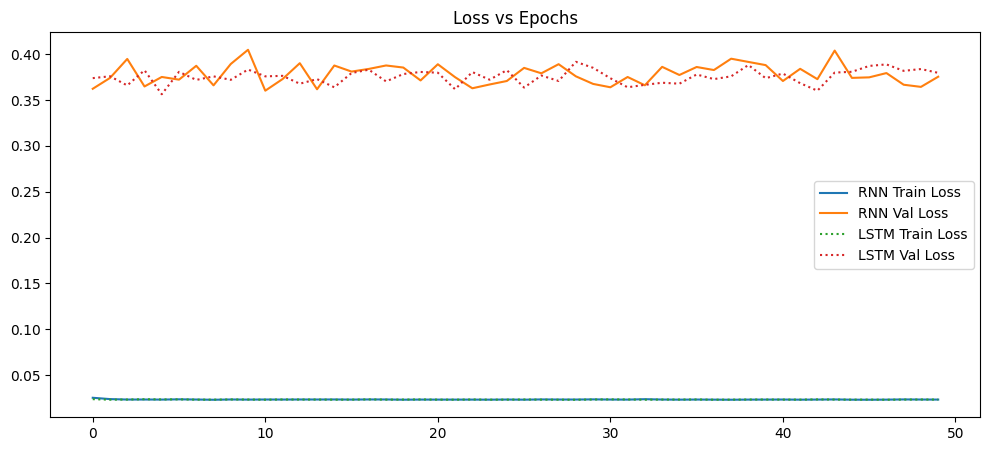

In [31]:
# Visualization
plt.figure(figsize=(12,5))
plt.plot(rnn_train_loss, label="RNN Train Loss")
plt.plot(rnn_val_loss, label="RNN Val Loss")
plt.plot(lstm_train_loss, label="LSTM Train Loss", linestyle='dotted')
plt.plot(lstm_val_loss, label="LSTM Val Loss", linestyle='dotted')
plt.legend()
plt.title("Loss vs Epochs")
plt.show()

In [32]:
# Predictions
rnn_model.eval()
lstm_model.eval()
with torch.no_grad():
    rnn_pred = rnn_model(test_X.to("cpu")).cpu().numpy()
    lstm_pred = lstm_model(test_X.to("cpu")).cpu().numpy()
    actual = test_Y.cpu().numpy()

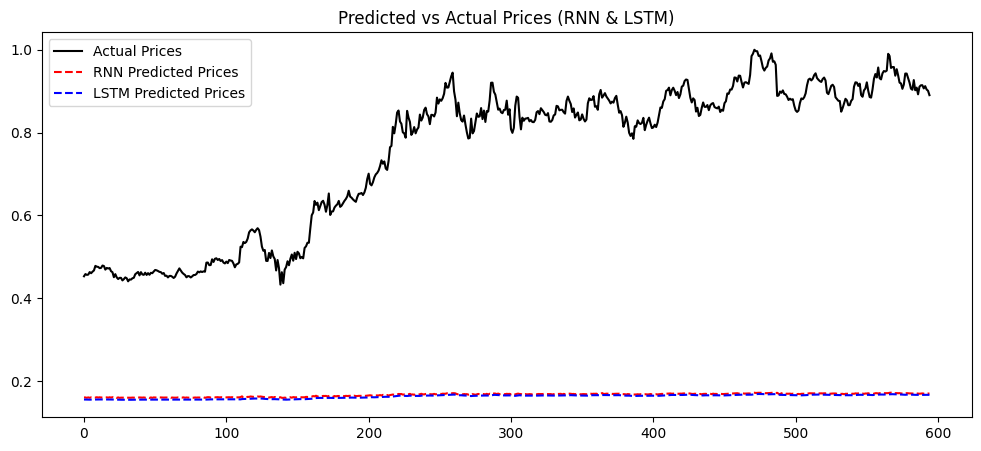

In [33]:
plt.figure(figsize=(12,5))
plt.plot(actual, label="Actual Prices", color='black')
plt.plot(rnn_pred, label="RNN Predicted Prices", linestyle='dashed', color='red')
plt.plot(lstm_pred, label="LSTM Predicted Prices", linestyle='dashed', color='blue')
plt.legend()
plt.title("Predicted vs Actual Prices (RNN & LSTM)")
plt.show()